# モデルに与えるデータを作成する方法を検討する

In [ ]:
import kagglehub
import polars as pl
from matplotlib import pyplot as plt
import csv
import cv2
from torch.nn import functional as F
import torch
import glob
from torchvision.transforms import v2
from torchvision.io import decode_image

c:\Users\siran\ML\Deep-Learning2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
DATA_DIR = r"C:\Users\siran\.cache\kagglehub\datasets\adityajn105\flickr8k\versions\1"
IMAGES_DIR = rf"{DATA_DIR}\Images"
CAPTIONS_CSV = rf"{DATA_DIR}\captions.csv"
WORD_DICT_CSV = rf"{DATA_DIR}\word_dict.csv"

In [9]:
df = pl.read_csv(CAPTIONS_CSV)

In [10]:
df.select(pl.col("image")), df.item(0, "image"), type(df.item(0, "image"))

(shape: (40_455, 1)
 ┌───────────────────────────┐
 │ image                     │
 │ ---                       │
 │ str                       │
 ╞═══════════════════════════╡
 │ 1000268201_693b08cb0e.jpg │
 │ 1000268201_693b08cb0e.jpg │
 │ 1000268201_693b08cb0e.jpg │
 │ 1000268201_693b08cb0e.jpg │
 │ 1000268201_693b08cb0e.jpg │
 │ …                         │
 │ 997722733_0cb5439472.jpg  │
 │ 997722733_0cb5439472.jpg  │
 │ 997722733_0cb5439472.jpg  │
 │ 997722733_0cb5439472.jpg  │
 │ 997722733_0cb5439472.jpg  │
 └───────────────────────────┘,
 '1000268201_693b08cb0e.jpg',
 str)

In [16]:
def makeImage(df, index):
    image_path_1 = rf"{IMAGES_DIR}\{df.item(0, "image")}"
    image = cv2.imread(image_path_1)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = torch.from_numpy(image).permute(2, 0, 1)
    
    return image

In [17]:
image = makeImage(df, 0)
image.shape, type(image)

(torch.Size([3, 500, 375]), torch.Tensor)

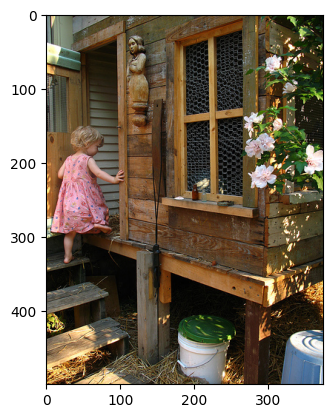

In [18]:
plt.imshow(image.permute(1, 2, 0))

In [28]:
transform = v2.Compose([
    v2.Resize((224, 224)),
    # v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [29]:
out = transform(image)

In [30]:
out.shape

torch.Size([3, 224, 224])

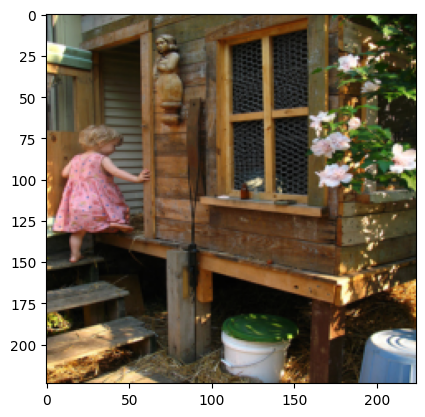

In [31]:
plt.imshow(out.permute(1, 2, 0))